Klastrowanie jest częścią uczenia nienadzorowanego. Chodzi w nim o to, aby pogrupować dane w klasy, w których obiekty mają podobne właściwości.

Przykłady:

1. Segmentacja rynku i klientów
2. Systemy rekomendacyjne
3. Rozpoznawanie wzorców, przetwarzanie obrazu, analiza sieci społecznościowych itp.

**Matematyczny opis problemu**

Niech $\mathcal{X}=\{x_1,x_2,\dots,x_n\}$ będzie zbiorem obserwacji. Niech $k\leq n$. Niech $\mathcal{S}=\{S_1,S_2,\dots,S_k\}$ będzie podziałem $\mathcal{X}$ na $k$ podzbiorów. **Inercja**, **suma kwadratów wewnątrz klastra**(**inertia**, **within-cluster sum of squares** or **WSS**) wyraża się wzorem
$$
\sum_{i=1}^k\sum_{x\in S_i}\Vert x-\mu_i\Vert^2 = \sum_{i=0}^{n}\min_{\mu_j \in C}(| |x_i - \mu_j||^2)
$$
gdzie $\mu_i$ to średnia wartość $S_i$, tj. $\mu_i=\frac{1}{\vert S_i\vert}\sum_{x\in S_i}x$, a $C=\{\mu_1 ,\mu_2,\dots,\mu_k\}$.

Celem jest minimalizowanie bezwładności dla danego $k$. Jest to problem NP-trudny, co oznacza, że jest bardzo trudny obliczeniowo. Algorytm $k$-średnich daje przybliżone rozwiązanie tego problemu.

## Algorytm k-średnich (algorytm Lloyda)

Celem algorytmu $k$-średnich jest podzielenie danych na $k$ nienakładających się grup. Przed rozpoczęciem algorytmu trzeba zdecydować, na ile klastrów lub podgrup ma zostać podzielony zbiór danych.

**Krok 1. Inicjalizacja** Wybierz losowo $k$ punktów w zbiorze danych. Punkty te nazywane są **centroidami**.

$\mathcal{C}=\{c_1,c_2,\dots,c_k\}$

**Krok 2. Tworzenie klastrów** Obliczamy odległości pomiędzy wszystkimi centroidami a punktami danych. Skupisko wokół centroidu $c_i$ składa się z tych punktów danych, które mają do niego najbliżej.

Dla każdego $i\in\{1, \dots , k\}$ niech $C_i:=\{x\in X:\Vert x-c_i\Vert\leq\Vert x-c_j\Vert$ dla wszystkich $j\neq i\}$.

**Krok 3. Przesuwanie centroidów** Dla punktów z jednego klastra, obliczamy ich średnią, a następnie przenosimy środek ciężkości tego klastra do nowej lokalizacji. I tak dla każdego klastra.

Dla każdego $i \in\{1, \dots, k\}$ przypisujemy zmiennej $c_i$ nową wartość - środek masy wszystkich punktów w $C_i$
$$
c_i:=\frac{1}{\vert C_i\vert}\sum_{x\in C_i}x
$$

**Powtarzamy** Kroki 2 i 3 do momentu, gdy centroidy nie przestaną się poruszać. Innymi słowy, dopóki $\mathcal{C}$ już się nie zmienia.

In [1]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from sklearn.cluster import KMeans
%matplotlib inline

## Baza irysów - animacja metody k-średnich

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target
X = iris.data[:,0:2]

In [4]:
Kmean = KMeans(n_clusters=3)
Kmean.fit(X)
clusters = Kmean.cluster_centers_

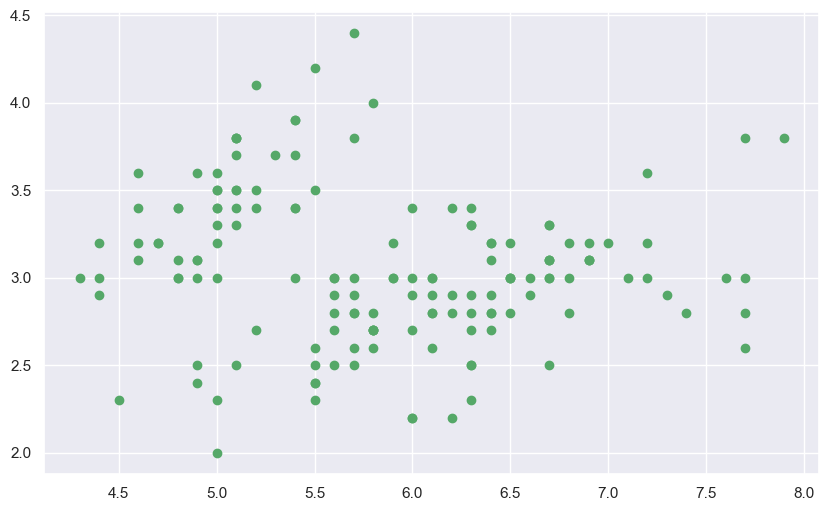

In [5]:
# create a figure and axes
fig = plt.figure(figsize=(10,6))
ax = plt.subplot()   

colors = ['g','r','y']
pts = sum([ax.plot(X[ k , 0],X[ k , 1],'o',color='g') for k in range(0,len(X))],[])
centroids = sum([ax.plot([],[],'o',color=colors[k],ms=15) for k in range(0,3)],[])
txt_title = ax.set_title('')

In [6]:
def drawframe(n):
    Kmean.set_params(n_clusters=3, init = 'random', max_iter=n+1, random_state=1978, n_init=1)
    Kmean.fit(X)
    clusters = Kmean.cluster_centers_
    centroids[0].set_data(clusters[0][0],clusters[0][1])
    centroids[1].set_data(clusters[1][0],clusters[1][1])
    centroids[2].set_data(clusters[2][0],clusters[2][1])

    for i in range(len(X)):
      if Kmean.labels_[i]==0:
        pts[i].set_color('g')
      elif Kmean.labels_[i]==1: 
        pts[i].set_color('r')
      else:
        pts[i].set_color('y')
    
    txt_title.set_text('Iteracja = {0:4d}'.format(n))
    return centroids

In [7]:
from matplotlib import animation
from IPython.display import HTML

anim = animation.FuncAnimation(fig, drawframe, frames=15, interval=1000, blit=True)
HTML(anim.to_html5_video())

Ostateczny wynik algorytmu zależy od losowej inicjalizacji centroidów w kroku 1.

Jeśli zmienimy w definicji funkcji drawframe() random_state na inną liczbę, to animacja będzie inna.

##### Zachowywanie animacji w pliku mp4

In [8]:
anim.save('k-means.mp4')

## Parametery Kmeans() w sklearn

**n_clusters** - liczba klastrów = liczba centroidów, domyślna wartość to 8

Na początku musimy określić liczbę klastrów. Jest to jedna z wad metody $k$-średnich.

**init** jest parametrem określającym metodę **inicjalizacji algorytmu**. Istnieją trzy możliwe wartości

1. init = 'random' - centroidy są losowane spośród punktów danych
2. **init = 'k-means++'** Inicjalizacja metodą k-means++ (poniżej opis).
3. init = tablica o kształcie (n_clusters, n_features) w której użytkownik podaje początkowe centroidy

**k-means++ algorytm inicjalizacji.**

Niech $D(x)$ oznacza odległość od punktu danych do najbliższego centrum spośród dotychczas wylosowanych.

1. Losujemy centroid $c_1$ jednostajnie z $\mathcal{X}$.
2. Mając $c_1,\dots,c_{i-1}$ losujemy $c_i$ pośród punktów $x\in\mathcal{X}$ z prawdopodobieństwem $\frac{D(x)^2}{\sum_{t\in\mathcal{X}}D(t )^2}$.
3. Powtarzamy krok 2, dopóki nie uzyskamy $k$ centroidów.


“k-means++: The advantages of careful seeding” Arthur, David, and Sergei Vassilvitskii, Proceedings of the eighteenth annual ACM-SIAM symposium on Discrete algorithms, Society for Industrial and Applied Mathematics (2007)
http://ilpubs.stanford.edu:8090/778/1/2006-13.pdf

Algorytm $k$-średnich zatrzymuje się po skończonej liczbie kroków. W przypadku dużego zbioru danych może to zająć dużo czasu. Jak widzieliśmy na animacji, centroidy zmieniają się nieznacznie po kilku krokach algorytmu. Dlatego rozsądne jest zatrzymanie algorytmu, jeśli sam się nie zatrzyma, po określonej liczbie kroków.

**max_iter** - maksymalna liczba iteracji algorytmu k-średnich dla pojedynczego uruchomienia; domyślna wartość to 300.

In [ ]:
Kmean.n_iter_

algorytm $k$-średnich (a także $k$-means++) są inicjowane w losowy sposób. Uzasadnione jest więc kilkukrotne uruchomienie algorytmu i wybranie najlepszego wyniku.

**n_init** - ile razy algorytm k-średnich będzie działał z różnymi centroidami. Wynikiem końcowym będzie **najlepszy wynik** z n_init kolejnych uruchomień, gdzie najlepszy oznacza o najmniejszej inercji. Wartość domyślna to **n_init=10**.

Mając wystarczającą ilość czasu, algorytm $k$-średnich w końcu się zatrzyma. Jeśli jednak różnice między kolejnymi iteracjami centroidów są bardzo małe, dla zaoszczędzenia czasu powinniśmy przerwać jego działanie.

**tol** - odległość względem normy Frobeniusa pomiędzy centroidami w dwóch kolejnych iteracji, poniżej której przerywane jest działanie algorytmu. Wartość domyślna to 0,0001.

Co to jest norma Frobeniusa? Załóżmy, że na pewnym etapie algorytmu mamy centroidy $k$ 

$c_1 = (c_{11},\dots,c_{1\ell})$

$c_2 = (c_{21},\dots,c_{2\ell})$

...

$c_k = (c_{k1},\dots,c_{k\ell})$

gdzie $\ell$ to liczba kolumn w danych. Niech $\bar{c}_1, \bar{c}_2,\dots, \bar{c}_k$ będą centroidami po następnym kroku. Odległość Frobeniusa między dwoma ciągami centoidów wynosi
$$
\sqrt{\sum_{i=1}^k\sum_{j=1}^\ell\vert c_{ij}-\bar{c}_{ij}\vert^2}.
$$
Jeśli ta odległość jest mniejsza niż **tol**, algorytm zostaje zakończony.

**algorithm** = 'lloyd' to wartość domyślna. 

**algorithm** = 'elkan' to odmiana algorytmu $k$-średnich autorstwa Charlesa Elkana opisana w [Using the Triangle Inequality to Accelerate $k$-Means](https://cseweb.ucsd.edu//~elkan/kmeansicml03.pdf)

## Mini-Batch K-Means - klastrowanie dużych zbiorów danych

MiniBatchKMeans to wariant algorytmu KMeans, który wykorzystuje mini-batche w celu skrócenia czasu obliczeń. Można go użyć zamiast algorytmu $k$-średnich podczas grupowania na **dużych zbiorach danych**.

Mini-batche to podzbiory danych wejściowych, losowo próbkowane w każdej iteracji. Mini-batche znacznie zmniejszają ilość wymaganych obliczeń.

Mini-Batch K-Means daje wyniki, które są na ogół tylko nieznacznie gorsze niż standardowy algorytm.

[K-means vs Mini Batch K-means: A comparison](https://upcommons.upc.edu/bitstream/handle/2117/23414/R13-8.pdf) - artykuł badawczy

In [9]:
Kmean = KMeans(n_clusters=3)
Kmean.fit(X)
Kmean.inertia_

37.08627024722932

In [10]:
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target'] = iris.target
X = iris.data[:,0:2]

In [16]:
from sklearn.cluster import MiniBatchKMeans
MBKmean = MiniBatchKMeans(n_clusters=3)
MBKmean.fit(X)
MBKmean.inertia_

37.11789036142498

## Jak znaleźć optymalne $k$ dla k-średnich

Dwa zbiory danych - blobs oraz irysy.

In [17]:
from sklearn.datasets import make_blobs

x, y = make_blobs(n_samples = 200, centers = 3, n_features=2, shuffle=True, random_state=31)


Text(0.5, 1.0, 'blobs')

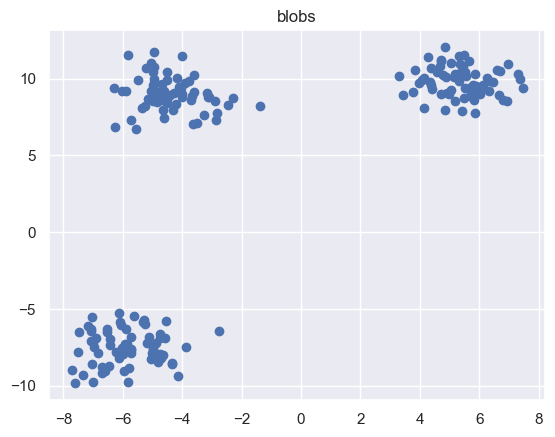

In [18]:
plt.scatter([x[i,0] for i in range(len(x))],[x[i,1] for i in range(len(x))])
plt.title('blobs')

Text(0.5, 1.0, 'iris')

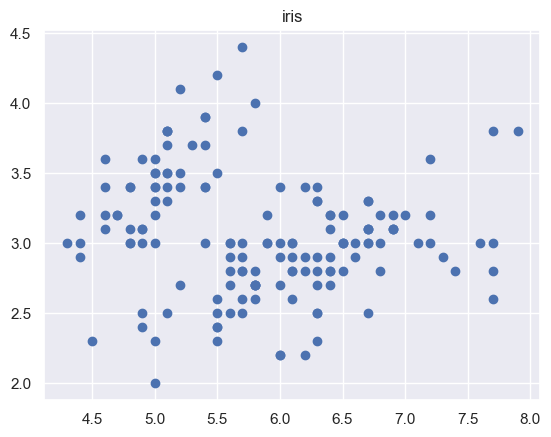

In [19]:
plt.scatter(X[ : , 0], X[ : , 1])
plt.title('iris')

Metoda łokciowa. Wykres inercji w zależności od $k$ i wybór takiego $k$, dla którego inercja zaczyna się zmniejszać coraz wolniej; ten punkt jest widoczny jako **łokieć**.

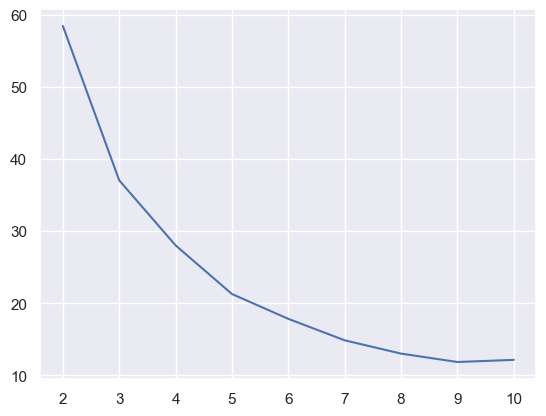

In [22]:
inertias = []

for i in range(2,11):
  km = KMeans(n_clusters=i)
  km.fit(X) # X dla irysów, x dla blobs
  inertias.append(km.inertia_)


plt.plot(range(2,11),inertias)
plt.show()

Metoda sylwetkowa

$a(i)=$ średnia odległość między $i$ a wszystkimi innymi punktami danych w tym samym klastrze.

$b(i)=$ najmniejsza średnia odległość $i$ do wszystkich punktów w dowolnym innym klastrze.

Współczynnik silhouette 
$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}.
$$

Właściwości współczynnika silhouette
* $-1\leq s(i)\leq 1$
* $s(i)$ jest bliskie 1, jeśli $a(i) \ll b(i)$ (tzn. $a(i)$ jest bardzo małe w porównaniu do $b(i)$)
* $s(i)$ bliskie 1 oznacza, że dane są odpowiednio pogrupowane.
* $s(i)$ jest bliskie -1, więc $i$ powinno być w sąsiednim klastrze.
* $s(i)$ bliskie zeru oznacza, że $i$ znajduje się na granicy dwóch naturalnych klastrów.

Funkcja **silhouette_score** zwraca średnią wartość współczynnika dla całego zbioru danych.

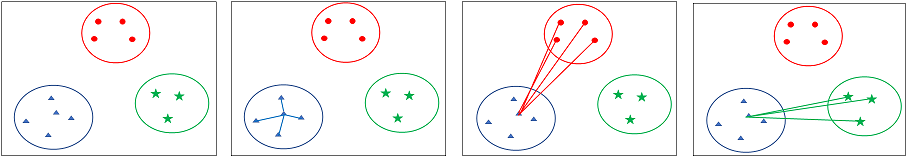

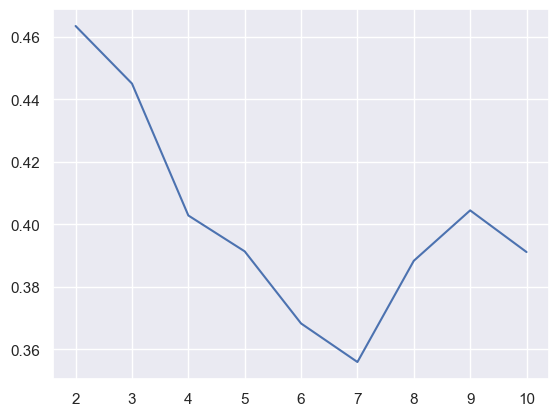

In [25]:
from sklearn.metrics import silhouette_score, silhouette_samples
sil = []

for i in range(2, 11):
  km = KMeans(n_clusters = i).fit(X)
  labels = km.labels_
  sil.append(silhouette_score(X, labels, metric = 'euclidean'))

plt.plot(range(2,11),sil)
plt.show()

### Wykres sylwetkowy

silhouette_score:  0.64794563666509


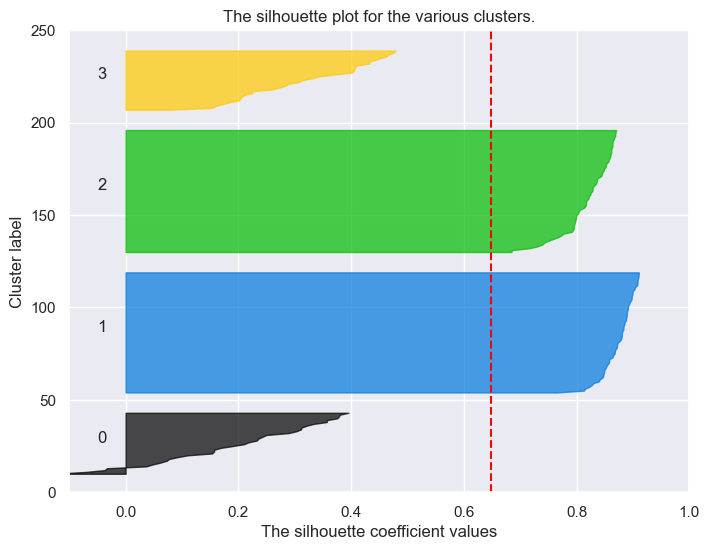

In [32]:
import matplotlib.cm as cm

n_clusters = 4

Kmean = KMeans(n_clusters=n_clusters)
Kmean.fit(x)
#centers = Kmean.cluster_centers_

cluster_labels = Kmean.labels_
plt.figure(figsize=(8,6))
plt.xlim([-0.1, 1])
plt.ylim([0, len(x) + (n_clusters + 1) * 10])
silhouette_avg = silhouette_score(x, cluster_labels)
print('silhouette_score: ',silhouette_avg)
sample_silhouette_values = silhouette_samples(x, cluster_labels)
y_lower = 10

for i in range(n_clusters):
  ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
  ith_cluster_silhouette_values.sort()
  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i

  color = cm.nipy_spectral(float(i) / n_clusters)
  plt.fill_betweenx(
  np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, 
  facecolor=color, edgecolor=color, alpha=0.7,)
  plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
  y_lower = y_upper + 10  # 10 for the 0 samples

plt.title("The silhouette plot for the various clusters.")
plt.xlabel("The silhouette coefficient values")
plt.ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.show()

Istnieją również inne metryki zaimplementowane w sklearn, które pomagają nam ocenić wydajność klastrowania, takie jak Indeks Calinskiego-Harabasza i Indeks Daviesa-Bouldina.

## Wartości odstające

Centroidy mogą być zmieniane przez wartości odstające lub wartości odstające mogą otrzymać własne skupienie zamiast być ignorowane. Należy rozważnyć usunięcie lub obcięcie wartości odstających przed grupowaniem.

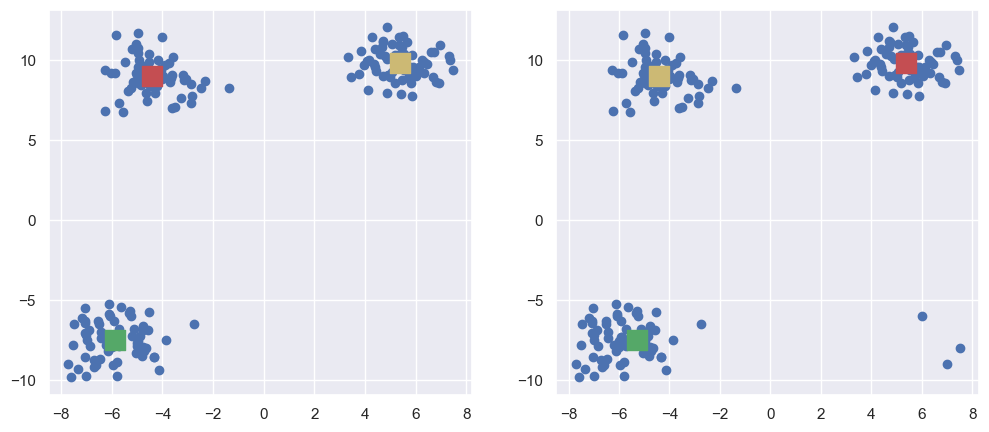

In [33]:
x1 = np.append(x,[[6.0,-6.0],[7.0,-9.0],[7.5,-8.0]], axis=0)

fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_size_inches(12, 5)

ax1.scatter([x[i,0] for i in range(len(x))],[x[i,1] for i in range(len(x))])
Kmean = KMeans(n_clusters = 3).fit(x)
clusters = Kmean.cluster_centers_
ax1.scatter(clusters[0][0],clusters[0][1], s=200, c='r', marker='s')
ax1.scatter(clusters[1][0],clusters[1][1], s=200, c='g', marker='s')
ax1.scatter(clusters[2][0],clusters[2][1], s=200, c='y', marker='s')


ax2.scatter([x1[i,0] for i in range(len(x1))],[x1[i,1] for i in range(len(x1))])
Kmean = KMeans(n_clusters = 3, random_state=1978).fit(x1)
clusters = Kmean.cluster_centers_
ax2.scatter(clusters[0][0],clusters[0][1], s=200, c='r', marker='s')
ax2.scatter(clusters[1][0],clusters[1][1], s=200, c='g', marker='s')
ax2.scatter(clusters[2][0],clusters[2][1], s=200, c='y', marker='s')



plt.show()

## Skalowanie

Rozważmy przykład

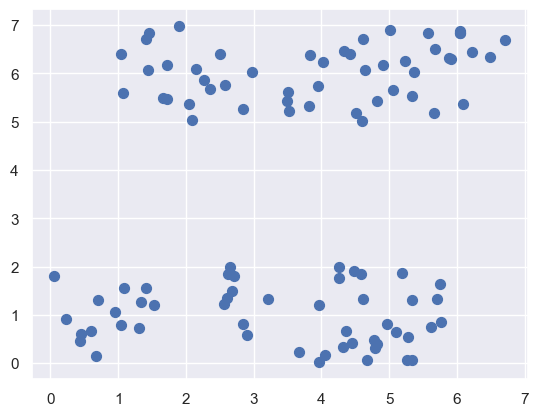

In [34]:
X= [6,2] * np.random.rand(100,2)
X1 =[1,5]+ [6,2] * np.random.rand(50,2)
X[50:100, :] = X1
plt.scatter(X[ : , 0], X[ :, 1], s = 50, c = 'b')
plt.show()

In [35]:
Kmean = KMeans(n_clusters = 2).fit(X)
clusters = Kmean.cluster_centers_

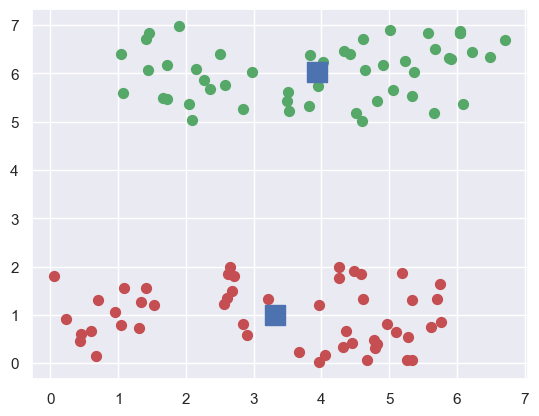

In [36]:
X0 = [X[i] for i in range(len(Kmean.labels_)) if Kmean.labels_[i]==0]
X1 = [X[i] for i in range(len(Kmean.labels_)) if Kmean.labels_[i]==1]

plt.scatter([X0[i][0] for i in range(len(X0))], [X0[i][1] for i in range(len(X0))], s = 50, c = 'g')
plt.scatter([X1[i][0] for i in range(len(X1))], [X1[i][1] for i in range(len(X1))], s = 50, c = 'r')
plt.scatter(clusters[0][0],clusters[0][1], s=200, c='b', marker='s')
plt.scatter(clusters[1][0],clusters[1][1], s=200, c='b', marker='s')
plt.show()

Teraz rozciągnijmy dane 100 razy na osi x...

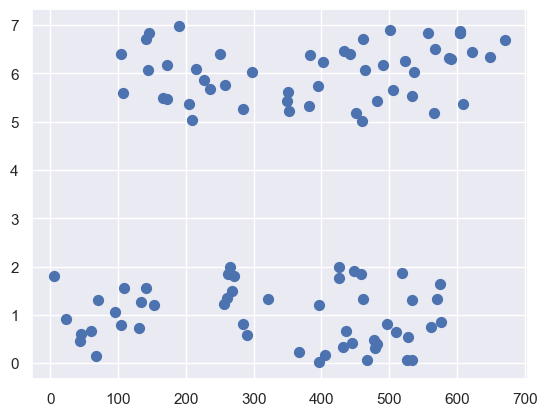

In [37]:
X_s = X *[100,1]
plt.scatter(X_s[ : , 0], X_s[ :, 1], s = 50, c = 'b')
plt.show() 

i po uruchomieniu algorytmu $k$-średnich

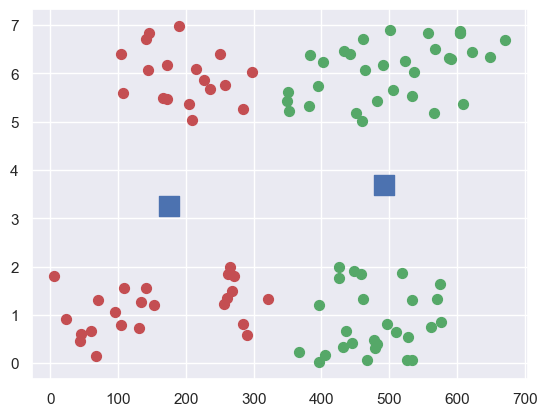

In [38]:
Kmean = KMeans(n_clusters = 2).fit(X_s)
clusters = Kmean.cluster_centers_

X_s0 = [X_s[i] for i in range(len(Kmean.labels_)) if Kmean.labels_[i]==0]
X_s1 = [X_s[i] for i in range(len(Kmean.labels_)) if Kmean.labels_[i]==1]

plt.scatter([X_s0[i][0] for i in range(len(X_s0))], [X_s0[i][1] for i in range(len(X_s0))], s = 50, c = 'g')
plt.scatter([X_s1[i][0] for i in range(len(X_s1))], [X_s1[i][1] for i in range(len(X_s1))], s = 50, c = 'r')

plt.scatter(clusters[0][0],clusters[0][1], s=200, c='b', marker='s')
plt.scatter(clusters[1][0],clusters[1][1], s=200, c='b', marker='s')
plt.show()

Pamiętajmy, by przeskalować dane przed uruchomieniem metody $k$-średnich